# Diffusion Models for Process Time Series <sup>🛠 pump skid</sup>

The last two days you trained diffusion models on faces. The machinery is identical here; only the data changes. Instead of a 3×64×64 image we denoise a **6×64 tensor** — six instrument tags, sixty-four seconds of a real, running centrifugal pump.

The data is the [Skoltech Anomaly Benchmark (SKAB)](https://github.com/waico/SKAB): a water circulation loop driven by an electric motor and pump, instrumented with casing accelerometers, motor current and voltage, discharge pressure, motor-body and process-fluid temperatures, and a flow meter. That is recognisably the instrument list on a refinery pump skid, which is what makes this transfer worth your time.

We train **one** unconditional DDPM on about two and a half hours of healthy operation, and then put it to three jobs you actually have:

| Job | On the unit |
|---|---|
| **Generate** | synthetic normal operation to test alarm logic against |
| **Impute** | a transmitter dies — reconstruct its trace from the tags that still work |
| **Detect** | flag a real upset, and name the instrument that saw it first |

Nothing here is labelled during training. The model only ever sees healthy data; every fault in Job 3 is one it has never encountered.

> **Runtime.** End-to-end in **4–9 minutes on any GPU** — a free Colab T4 is ample. The network is 1.9M parameters and peak GPU memory is **28 MB**, so nothing here needs a big card.
> On **CPU it takes roughly two hours** (measured 18× slower on 4 threads), so use a GPU runtime: *Runtime → Change runtime type → T4 GPU*.

## Setup

In [1]:
#@title imports
import math, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)
print("device:", device, "| torch", torch.__version__)

device: mps | torch 2.8.0


## The rig

SKAB is a closed water loop: a tank, an electric motor driving a centrifugal pump, and throttling valves on the pump's suction and discharge. Eight tags are logged at roughly 1 Hz.

| Tag | Units | What it is | Refinery analogue |
|---|---|---|---|
| `Accelerometer1RMS`, `Accelerometer2RMS` | g | casing vibration, two axes | vibration probes on a pump |
| `Current` | A | motor amperage | motor load |
| `Voltage` | V | motor voltage | bus voltage |
| `Pressure` | Bar | loop pressure downstream of the pump | discharge pressure |
| `Temperature` | °C | motor body temperature | bearing / winding temperature |
| `Thermocouple` | °C | circulating fluid temperature | process temperature |
| `Volume Flow RateRMS` | L/min | loop flow | flow transmitter |

We use two parts of the corpus:

- **`anomaly-free/anomaly-free.csv`** — one continuous healthy run, 9,405 seconds ending at 16:16:47. This is all the model ever trains on.
- **`other/5.csv` … `other/14.csv`** — ten separate fault experiments recorded at the same operating point, each with a documented physical cause and per-second ground-truth labels. These are the held-out test set.

The remaining folders (`valve1`, `valve2`, `other/1`–`4`) were recorded at *different* flow setpoints — 32 and 76 L/min against our 125 L/min. Mixing them in would mean the "detector" was really just noticing a setpoint change, so we leave them out. Sorting that out is most of the work in a real historian pull too.

SKAB is published under GPL-3.0 by Katser & Kozitsin; we download it at run time rather than redistributing it.

In [2]:
#@title download SKAB
BASE  = "https://raw.githubusercontent.com/waico/SKAB/master/data"
WANT  = {"anomaly-free": ["anomaly-free.csv"], "other": [f"{i}.csv" for i in range(5, 15)]}
root  = Path("skab")

for folder, names in WANT.items():
    (root / folder).mkdir(parents=True, exist_ok=True)
    for n in names:
        dst = root / folder / n
        if not dst.exists():
            urllib.request.urlretrieve(f"{BASE}/{folder}/{n}", dst)

FAULTS = {                                        # from SKAB's own data/README.md
    5:  "rotor imbalance (sharp)",       6:  "rotor imbalance (linear)",
    7:  "rotor imbalance (step)",        8:  "rotor imbalance (impulse)",
    9:  "rotor imbalance (exponential)", 10: "slow water increase",
    11: "sudden water increase",         12: "cavitation (tank drained)",
    13: "cavitation (two-phase inlet)",  14: "increased water temperature",
}

af = pd.read_csv(root / "anomaly-free" / "anomaly-free.csv", sep=";", parse_dates=["datetime"])
SENSORS = [c for c in af.columns if c != "datetime"]
print(f"healthy run: {len(af):,} rows | {af.datetime.min()} -> {af.datetime.max()}")
print(f"fault experiments: {len(FAULTS)} | sensors: {len(SENSORS)}")

healthy run: 9,405 rows | 2020-02-08 13:30:47 -> 2020-02-08 16:16:47
fault experiments: 10 | sensors: 8


## Know your instruments

Before modelling anything, look at what the instruments are actually telling you. This is the step that gets skipped, and it is the one that decides whether the rest works.

Three cheap diagnostics per tag:

- **lag-1 autocorrelation** — does this second look like the last one? A real physical signal sampled at 1 Hz is smooth; white noise is not.
- **distinct values** — how many levels does the transmitter actually resolve over 9,405 samples?
- **top-value share** — what fraction of the record sits on a single number?

In [3]:
#@title instrument audit
rows = []
for c in SENSORS:
    x = af[c]
    rows.append({"lag-1 acf":     x.autocorr(1),
                 "distinct":      x.nunique(),
                 "top value %":   100 * x.value_counts(normalize=True).iloc[0],
                 "std":           x.std()})
audit = pd.DataFrame(rows, index=SENSORS).sort_values("lag-1 acf", ascending=False)
print(audit.round(3).to_string())

                     lag-1 acf  distinct  top value %     std
Thermocouple             1.000      6318        0.138   0.731
Volume Flow RateRMS      0.949       289       18.320   1.605
Temperature              0.938      7635        0.053   0.667
Accelerometer1RMS        0.927      6941        0.064   0.005
Accelerometer2RMS        0.887      6667        0.074   0.004
Pressure                 0.107         9       54.918   0.253
Current                  0.074      9062        0.032   0.486
Voltage                  0.009      8210        0.043  10.981


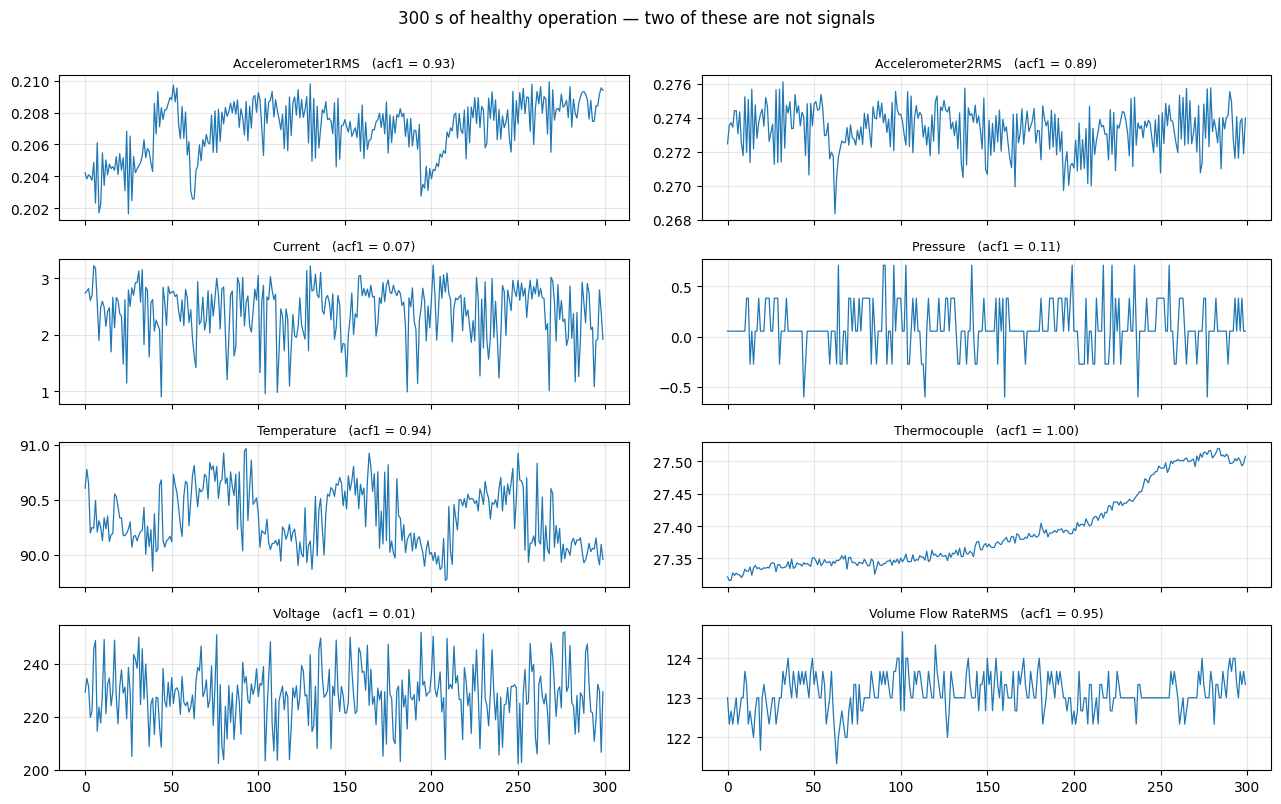

In [4]:
#@title look at 300 seconds of every tag
seg = af.iloc[1000:1300]
fig, axes = plt.subplots(4, 2, figsize=(13, 8), sharex=True)
for ax, c in zip(axes.ravel(), SENSORS):
    ax.plot(seg[c].values, lw=0.9)
    ax.set_title(f"{c}   (acf1 = {af[c].autocorr(1):.2f})", fontsize=9)
    ax.grid(alpha=0.3)
fig.suptitle("300 s of healthy operation — two of these are not signals", y=1.0)
plt.tight_layout(); plt.show()

Two tags fail the audit, and they fail it badly:

- **`Pressure`** resolves to about **nine distinct values** across the whole record, with over half of every sample sitting on one number. It is a coarse quantiser flickering between adjacent levels, not a pressure trace. Its lag-1 autocorrelation (~0.11) is what you would expect from that.
- **`Voltage`** has lag-1 autocorrelation of about **0.01** — statistically indistinguishable from white noise — and its distribution is identical in healthy and faulted operation. A 50 Hz supply sampled once per second is aliased into noise.

Neither carries recoverable temporal structure. Feeding them to the model costs capacity and, worse, injects an irreducible noise floor into every reconstruction-error score we compute later. We drop them.

This is not a quirk of an academic dataset. Dead tags, stuck transmitters and aliased sampling are what a historian pull looks like, and finding them is engineering work that no amount of model tuning substitutes for. In Job 3 you will see this single decision buy more detection performance than any hyperparameter.

In [5]:
#@title keep the six tags that carry signal
CHANNELS = [c for c in SENSORS if c not in ("Pressure", "Voltage")]
C = len(CHANNELS)
print(f"modelling {C} channels:")
for c in CHANNELS: print("  -", c)

modelling 6 channels:
  - Accelerometer1RMS
  - Accelerometer2RMS
  - Current
  - Temperature
  - Thermocouple
  - Volume Flow RateRMS


## Windows, splits, and one nasty overlap

The model sees fixed-length windows, not the whole trend. We use **64 seconds** — long enough to contain the dynamics of a vibration excursion, short enough that a small network covers it.

Three things have to be right or the results downstream are fiction:

1. **A hidden duplicate.** The healthy run ends at 16:16:47 and `other/5.csv` begins at 16:06:48 — they overlap by **572 byte-identical rows**. Left alone, the first 572 seconds of a *test* file sit inside the *training* set. We truncate the healthy run at the moment `other/5` starts.
2. **Split by time, not at random.** Windows overlap, so a random split puts near-copies of the same seconds on both sides. Validation is the last 15% of the healthy run, taken as a contiguous block.
3. **Standardise on training statistics only.** Tag scales span three orders of magnitude (flow ~125 L/min against accelerometers ~0.2 g). Without per-channel standardisation the loss is a flow regression and the accelerometers are invisible. Computing the mean and standard deviation over train *and* test leaks fault statistics into the normalisation and flatters every score.

In [6]:
#@title build windows
WINDOW    = 64      # seconds per window
VAL_FRAC  = 0.15
STRIDE_TE = 4       # test stride — 4 s hop keeps the test set a manageable size

t_other5 = pd.read_csv(root / "other" / "5.csv", sep=";", parse_dates=["datetime"]).datetime.min()
n_before = len(af)
af_clean = af[af.datetime < t_other5]
print(f"removed {n_before - len(af_clean)} healthy rows that are byte-identical to the start of other/5.csv")

def windows(arr, length, stride):
    n = (len(arr) - length) // stride + 1
    return np.stack([arr[i * stride: i * stride + length] for i in range(n)]) if n > 0 else np.zeros((0, length, arr.shape[1]))

vals  = af_clean[CHANNELS].values.astype(np.float64)
cut   = int(len(vals) * (1 - VAL_FRAC))
mu, sd = vals[:cut].mean(0), vals[:cut].std(0)          # train statistics only

series  = (vals - mu) / sd                              # standardised full healthy run
x_train = windows(series[:cut], WINDOW, 1).astype(np.float32)
x_val   = windows(series[cut:], WINDOW, 1).astype(np.float32)

x_test, y_test, exp_id = [], [], []
for i, name in FAULTS.items():
    df = pd.read_csv(root / "other" / f"{i}.csv", sep=";")
    w  = windows((df[CHANNELS].values.astype(np.float64) - mu) / sd, WINDOW, STRIDE_TE).astype(np.float32)
    lab = windows(df["anomaly"].values.reshape(-1, 1).astype(np.float64), WINDOW, STRIDE_TE).mean(1).ravel() > 0.5
    x_test.append(w); y_test.append(lab); exp_id += [i] * len(w)
x_test, y_test, exp_id = np.concatenate(x_test), np.concatenate(y_test), np.array(exp_id)

print(f"train {x_train.shape} | val {x_val.shape} | test {x_test.shape}  ({y_test.mean():.0%} faulted)")

removed 572 healthy rows that are byte-identical to the start of other/5.csv
train (7445, 64, 6) | val (1262, 64, 6) | test (2614, 64, 6)  (37% faulted)


A caveat worth stating out loud: stride-1 windowing turns 7,500 seconds into 7,445 windows, but consecutive windows share 63 of their 64 samples. The **effective** sample size is closer to 120 independent windows. This is a small-data problem dressed up as a large one — expect the model to overfit, and do not read the window count as a dataset size.

channel mean by third of the healthy run (train sigma units):
                     third 1  third 2  third 3
Accelerometer1RMS      -1.01     0.21     0.79
Accelerometer2RMS       1.24    -0.52    -0.72
Current                 0.02     0.03    -0.05
Temperature             1.12    -0.35    -0.77
Thermocouple           -1.22     0.18     1.04
Volume Flow RateRMS    -1.18     0.31     0.87


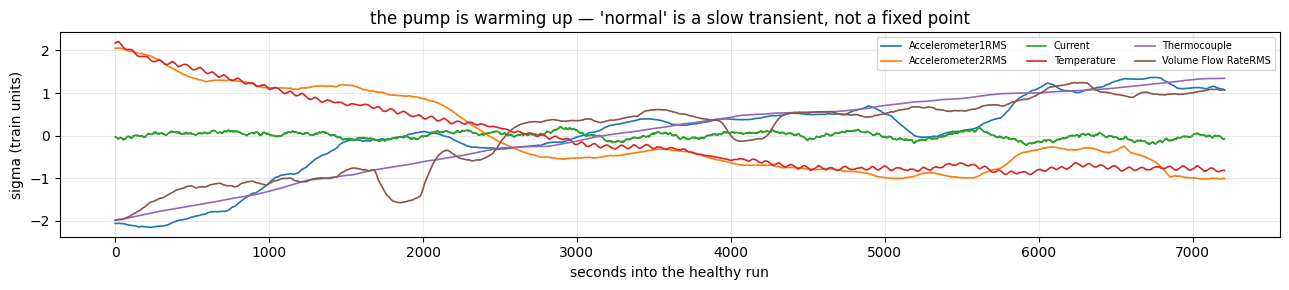

In [7]:
#@title is "normal" actually steady state?
z = series[:cut]
thirds = np.array_split(z, 3)
drift = pd.DataFrame({f"third {i+1}": t.mean(0) for i, t in enumerate(thirds)}, index=CHANNELS)
print("channel mean by third of the healthy run (train sigma units):")
print(drift.round(2).to_string())

fig, ax = plt.subplots(figsize=(13, 3))
for i, c in enumerate(CHANNELS):
    ax.plot(np.convolve(z[:, i], np.ones(300)/300, mode="valid"), lw=1.2, label=c)
ax.set_xlabel("seconds into the healthy run"); ax.set_ylabel("sigma (train units)")
ax.set_title("the pump is warming up — 'normal' is a slow transient, not a fixed point")
ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=3); plt.tight_layout(); plt.show()

The healthy record is not steady state. Across the run the fluid thermocouple climbs about two standard deviations and the vibration and flow tags drift with it — the loop is warming up. The model therefore learns the *envelope of a warm-up*, not a single operating point, and our validation block is the tail end of that drift, which is why validation loss sits above training loss throughout. That is a property of the data, not a bug in the training loop.

## The forward process

Identical to the image case. Add Gaussian noise on a fixed schedule:

`x_t = sqrt(ᾱ_t)·x_0 + sqrt(1-ᾱ_t)·ε`,  `ε ~ N(0, I)`

One choice differs from the face labs. The usual cosine schedule drives `β` to 0.999 at the final step, which leaves `α_T ≈ 0.001`; the reverse step divides by `sqrt(α_T)`, amplifying any error by ~30× at exactly the step where the model is least certain. On 64-sample windows with a 1.9M-parameter network that is enough to blow the sampler up — generated windows came out at three times the correct variance. Clamping `β` at **0.05** keeps the terminal signal-to-noise ratio low enough to start sampling from pure noise while keeping every reverse step numerically calm.

In [8]:
#@title noise schedule
T_STEPS  = 400
BETA_MAX = 0.05

def cosine_betas(T, beta_max):
    f     = lambda u: torch.cos((u + 0.008) / 1.008 * math.pi / 2) ** 2
    u     = torch.linspace(0, 1, T + 1)
    abar  = f(u) / f(torch.tensor(0.0))
    return (1 - abar[1:] / abar[:-1]).clamp(1e-8, beta_max)

betas      = cosine_betas(T_STEPS, BETA_MAX).to(device)
alphas     = 1.0 - betas
abar       = torch.cumprod(alphas, 0)
abar_prev  = torch.cat([torch.ones(1, device=device), abar[:-1]])
sqrt_abar  = abar.sqrt()
sqrt_1mab  = (1 - abar).sqrt()
post_var   = (betas * (1 - abar_prev) / (1 - abar)).clamp(min=1e-20)
coef_x0    = abar_prev.sqrt() * betas / (1 - abar)
coef_xt    = alphas.sqrt() * (1 - abar_prev) / (1 - abar)

def q_sample(x0, t, noise):
    return sqrt_abar[t][:, None, None] * x0 + sqrt_1mab[t][:, None, None] * noise

print(f"T = {T_STEPS} | beta {betas[0]:.2e} -> {betas[-1]:.3f} | sqrt(abar_T) = {sqrt_abar[-1]:.4f}")

T = 400 | beta 1.12e-04 -> 0.050 | sqrt(abar_T) = 0.0557


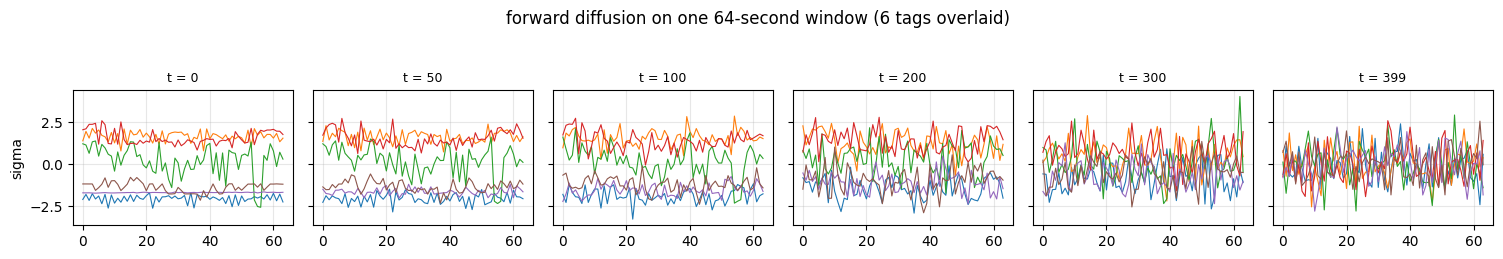

In [9]:
#@title watch a real window dissolve
w0 = torch.tensor(x_train[500:501]).permute(0, 2, 1).to(device)
steps = [0, 50, 100, 200, 300, 399]
fig, axes = plt.subplots(1, len(steps), figsize=(15, 2.4), sharey=True)
for ax, s in zip(axes, steps):
    t  = torch.full((1,), s, device=device, dtype=torch.long)
    xt = q_sample(w0, t, torch.randn_like(w0))[0].cpu().numpy()
    for ch in range(C): ax.plot(xt[ch], lw=0.8)
    ax.set_title(f"t = {s}", fontsize=9); ax.grid(alpha=0.3)
axes[0].set_ylabel("sigma")
fig.suptitle("forward diffusion on one 64-second window (6 tags overlaid)", y=1.06)
plt.tight_layout(); plt.show()

## The denoiser

A 1D U-Net over `(batch, 6, 64)`. The changes from the image U-Net are all consequences of the axis count and the sequence length:

- **`Conv1d` throughout**, kernel 3. Two downsamples take 64 → 32 → 16; with two residual blocks per level the receptive field comfortably spans the full window, so no attention is needed at this length.
- **`GroupNorm`, never `BatchNorm`.** Batch statistics leak across windows, and at inference the running averages are wrong for a distribution the model is being asked to score. This matters more here than for images, because we later use the loss itself as an anomaly score.
- **Sinusoidal timestep embedding** injected as a per-channel scale and shift (FiLM) inside every residual block.
- **Zero-initialised output convolutions**, so each block starts as identity and early training is stable.

In [10]:
#@title 1D UNet
class SinusoidalTime(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        ang  = t.float()[:, None] * freq[None]
        return torch.cat([ang.sin(), ang.cos()], dim=1)

class ResBlock(nn.Module):
    def __init__(self, c_in, c_out, t_dim, groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(groups, c_in), c_in)
        self.conv1 = nn.Conv1d(c_in, c_out, 3, padding=1)
        self.emb   = nn.Linear(t_dim, c_out * 2)                 # -> scale, shift
        self.norm2 = nn.GroupNorm(min(groups, c_out), c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, 3, padding=1)
        self.skip  = nn.Conv1d(c_in, c_out, 1) if c_in != c_out else nn.Identity()
        nn.init.zeros_(self.conv2.weight); nn.init.zeros_(self.conv2.bias)
    def forward(self, x, temb):
        h = self.conv1(F.silu(self.norm1(x)))
        scale, shift = self.emb(F.silu(temb))[:, :, None].chunk(2, dim=1)
        h = F.silu(self.norm2(h) * (1 + scale) + shift)
        return self.conv2(h) + self.skip(x)

class UNet1D(nn.Module):
    def __init__(self, channels, base=64, mults=(1, 2, 2), t_dim=128):
        super().__init__()
        self.time = nn.Sequential(SinusoidalTime(base), nn.Linear(base, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        self.stem = nn.Conv1d(channels, base, 3, padding=1)
        widths, prev = [base * m for m in mults], base

        self.down, self.pool = nn.ModuleList(), nn.ModuleList()
        for i, w in enumerate(widths):
            self.down.append(nn.ModuleList([ResBlock(prev, w, t_dim), ResBlock(w, w, t_dim)]))
            self.pool.append(nn.Conv1d(w, w, 4, stride=2, padding=1) if i < len(widths) - 1 else nn.Identity())
            prev = w

        self.mid1, self.mid2 = ResBlock(prev, prev, t_dim), ResBlock(prev, prev, t_dim)

        self.up, self.upsample = nn.ModuleList(), nn.ModuleList()
        for i, w in reversed(list(enumerate(widths))):
            self.upsample.append(nn.ConvTranspose1d(prev, prev, 4, stride=2, padding=1) if i < len(widths) - 1 else nn.Identity())
            self.up.append(nn.ModuleList([ResBlock(prev + w, w, t_dim), ResBlock(w, w, t_dim)]))
            prev = w

        self.out_norm = nn.GroupNorm(8, prev)
        self.out      = nn.Conv1d(prev, channels, 3, padding=1)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)

    def forward(self, x, t):
        temb, h, skips = self.time(t), self.stem(x), []
        for (b1, b2), pool in zip(self.down, self.pool):
            h = b2(b1(h, temb), temb); skips.append(h); h = pool(h)
        h = self.mid2(self.mid1(h, temb), temb)
        for (b1, b2), ups in zip(self.up, self.upsample):
            h = ups(h); h = b2(b1(torch.cat([h, skips.pop()], dim=1), temb), temb)
        return self.out(F.silu(self.out_norm(h)))

model = UNet1D(C).to(device)
print(f"UNet params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

UNet params: 1.91M


## Training

Standard ε-prediction objective — predict the noise that was added, minimise MSE. An exponential moving average of the weights is kept for sampling; with only ~120 effective windows the raw weights are noticeably noisier than their average.

In [11]:
#@title training config
EPOCHS     = 20
BATCH_SIZE = 128
MAX_LR     = 3e-4
EMA_DECAY  = 0.995

train_t = torch.tensor(x_train).permute(0, 2, 1)          # (N, C, L)
val_t   = torch.tensor(x_val).permute(0, 2, 1)
test_t  = torch.tensor(x_test).permute(0, 2, 1)

loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(train_t),
                                     batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print(f"{len(train_t):,} train windows | {len(loader)} batches/epoch | {EPOCHS * len(loader)} steps")

7,445 train windows | 58 batches/epoch | 1160 steps


In [12]:
#@title train
import copy
ema = copy.deepcopy(model).eval().requires_grad_(False)
opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=MAX_LR, total_steps=EPOCHS * len(loader), pct_start=0.1)

@torch.no_grad()
def val_loss():
    g = torch.Generator().manual_seed(1)
    xv = val_t.to(device)
    t  = torch.randint(0, T_STEPS, (len(xv),), generator=g).to(device)
    e  = torch.randn(xv.shape, generator=g).to(device)
    return F.mse_loss(ema(q_sample(xv, t, e), t), e).item()

train_hist, val_hist = [], []
pbar = tqdm(range(EPOCHS), desc="training")
for epoch in pbar:
    model.train(); running, seen = 0.0, 0
    for (xb,) in loader:
        xb = xb.to(device)
        t  = torch.randint(0, T_STEPS, (len(xb),), device=device)
        e  = torch.randn_like(xb)
        loss = F.mse_loss(model(q_sample(xb, t, e), t), e)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        with torch.no_grad():
            for p, q in zip(ema.parameters(), model.parameters()): p.mul_(EMA_DECAY).add_(q, alpha=1 - EMA_DECAY)
        running += loss.item() * len(xb); seen += len(xb)
    train_hist.append(running / seen); val_hist.append(val_loss())
    pbar.set_postfix(train=f"{train_hist[-1]:.4f}", val=f"{val_hist[-1]:.4f}")
print("training complete ✓")

training:   0%|          | 0/20 [00:00<?, ?it/s]

training complete ✓


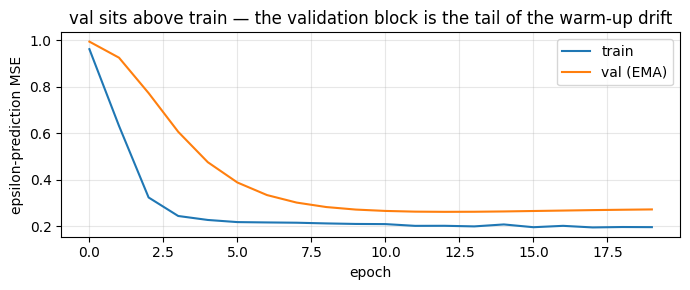

In [13]:
#@title loss curves
plt.figure(figsize=(7, 3))
plt.plot(train_hist, label="train", lw=1.5)
plt.plot(val_hist,  label="val (EMA)", lw=1.5)
plt.xlabel("epoch"); plt.ylabel("epsilon-prediction MSE")
plt.title("val sits above train — the validation block is the tail of the warm-up drift")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

## Sampling

The reverse step is written in its **x₀-parameterised** form: predict ε, convert to an estimate of the clean window, clamp that estimate to ±5σ, then take the exact posterior mean. Algebraically this is the same update as the ε form, but the clamp gives the sampler somewhere to fail gracefully. Without it, one bad ε prediction at high noise propagates into every subsequent step.

The same function does inpainting. Passing a mask runs the **RePaint** scheme (Lugmayr et al., 2022): at every reverse step the observed entries are overwritten with the *known* data noised to that step's level, so the model only ever fills the holes and the rest stays pinned to measurement. The `resample` loop repeats each reverse step a couple of times with a one-step re-noise in between, letting the filled region reconcile with its surroundings instead of being spliced in cold. This is a cheap, per-step simplification of RePaint's published jump-back schedule, which shuttles ten steps at a time and costs about ten times a plain sample; at this window size the simplified version is enough.

In [14]:
#@title sampler (unconditional + RePaint inpainting)
@torch.no_grad()
def sample(net, n, mask=None, known=None, resample=1, clip=5.0, seed=0):
    """mask == 1 marks OBSERVED entries; the model fills the rest."""
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, C, WINDOW, generator=g).to(device)
    for i in reversed(range(T_STEPS)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        for r in range(resample if mask is not None else 1):
            if mask is not None:                                     # pin the observed region
                e = torch.randn(known.shape, generator=g).to(device)
                x = mask * (sqrt_abar[i] * known + sqrt_1mab[i] * e) + (1 - mask) * x
            eps = net(x, t)
            x0  = ((x - sqrt_1mab[i] * eps) / sqrt_abar[i]).clamp(-clip, clip)
            mean = coef_x0[i] * x0 + coef_xt[i] * x
            if i > 0:
                x = mean + post_var[i].sqrt() * torch.randn(x.shape, generator=g).to(device)
            else:
                x = mean
            if mask is not None and r < resample - 1 and i > 0:      # RePaint jump-back
                z = torch.randn(x.shape, generator=g).to(device)
                x = (1 - betas[i]).sqrt() * x + betas[i].sqrt() * z
    return mask * known + (1 - mask) * x if mask is not None else x

## Job 1 — generating synthetic normal operation

The first job. Draw 256 windows of healthy operation that never happened, and check whether they are statistically the real thing.

"Looks plausible" is not a standard. Four numbers decide it:

- **per-channel standard deviation** — are the marginals the right width?
- **lag-1 and lag-8 autocorrelation** — is the *dynamics* right, not just the histogram? This is the one that separates a time-series model from a scatter of independent points.
- **cross-channel correlation matrix** — does flow still move with vibration the way it does on the real unit? Reported as Frobenius error against the real matrix.

In [15]:
#@title sample 256 synthetic windows
gen = sample(ema, 256, seed=7).cpu().numpy()
ref = x_train[np.random.RandomState(1).choice(len(x_train), 256, replace=False)].transpose(0, 2, 1)
print("generated:", gen.shape)

generated: (256, 6, 64)


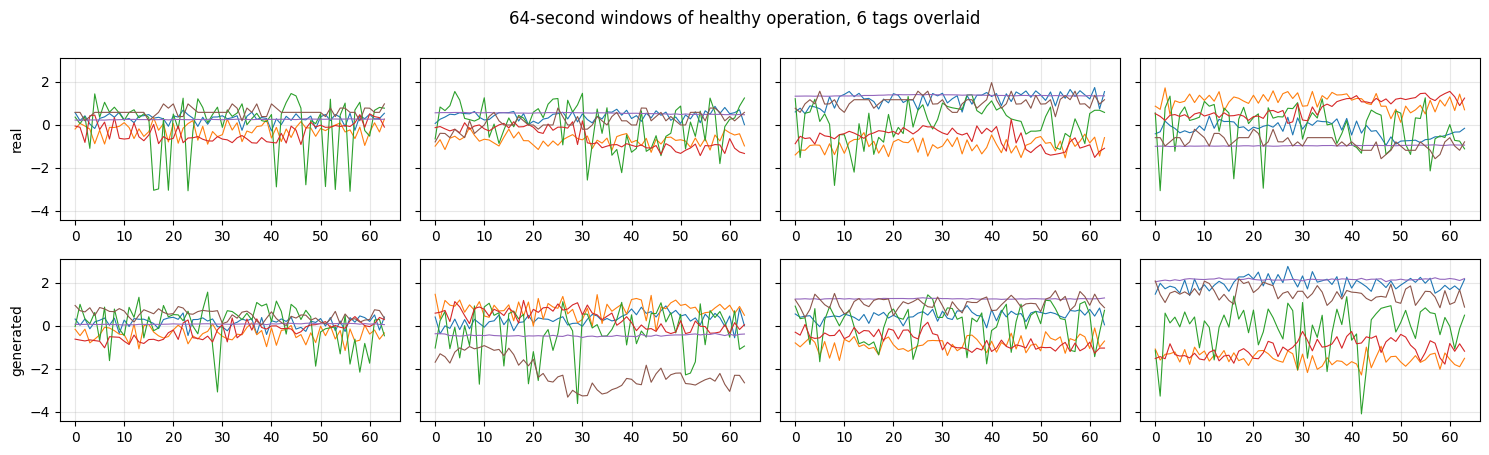

In [16]:
#@title real vs generated — eyeball first
fig, axes = plt.subplots(2, 4, figsize=(15, 4.5), sharey=True)
for j in range(4):
    for ch in range(C): axes[0, j].plot(ref[j, ch], lw=0.8)
    for ch in range(C): axes[1, j].plot(gen[j, ch], lw=0.8)
    axes[0, j].grid(alpha=0.3); axes[1, j].grid(alpha=0.3)
axes[0, 0].set_ylabel("real"); axes[1, 0].set_ylabel("generated")
fig.suptitle("64-second windows of healthy operation, 6 tags overlaid", y=1.0)
plt.tight_layout(); plt.show()

                     std real  std gen  acf1 real  acf1 gen
Accelerometer1RMS       1.010    0.915      0.027    -0.034
Accelerometer2RMS       0.991    0.917     -0.190    -0.234
Current                 1.004    1.024      0.051     0.043
Temperature             0.995    0.909      0.612     0.608
Thermocouple            0.998    0.967      0.857     0.232
Volume Flow RateRMS     1.036    0.970      0.510     0.438

overall  std 1.006 -> 0.952 | acf1 0.133 -> 0.113 | acf8 0.071 -> 0.081
cross-channel correlation Frobenius error: 0.195  (4.4% of ||C_real||)


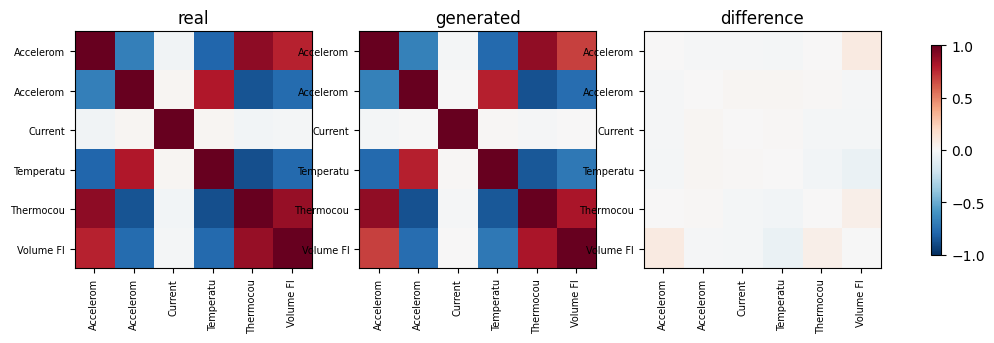

In [17]:
#@title real vs generated — the numbers that matter
def acf(a, k):
    a = a - a.mean(-1, keepdims=True)
    return float((a[..., :-k] * a[..., k:]).mean() / (a ** 2).mean())

tab = pd.DataFrame({
    "std real":  [ref[:, i].std() for i in range(C)],
    "std gen":   [gen[:, i].std() for i in range(C)],
    "acf1 real": [acf(ref[:, i], 1) for i in range(C)],
    "acf1 gen":  [acf(gen[:, i], 1) for i in range(C)],
}, index=CHANNELS)
print(tab.round(3).to_string())

corr_real = np.corrcoef(ref.transpose(0, 2, 1).reshape(-1, C).T)
corr_gen  = np.corrcoef(gen.transpose(0, 2, 1).reshape(-1, C).T)
err = np.linalg.norm(corr_real - corr_gen)
print(f"\noverall  std {ref.std():.3f} -> {gen.std():.3f} | acf1 {acf(ref,1):.3f} -> {acf(gen,1):.3f} | acf8 {acf(ref,8):.3f} -> {acf(gen,8):.3f}")
print(f"cross-channel correlation Frobenius error: {err:.3f}  ({100*err/np.linalg.norm(corr_real):.1f}% of ||C_real||)")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, M, ttl in [(axes[0], corr_real, "real"), (axes[1], corr_gen, "generated"), (axes[2], corr_real - corr_gen, "difference")]:
    im = ax.imshow(M, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(C)); ax.set_xticklabels([c[:9] for c in CHANNELS], rotation=90, fontsize=7)
    ax.set_yticks(range(C)); ax.set_yticklabels([c[:9] for c in CHANNELS], fontsize=7)
    ax.set_title(ttl)
fig.colorbar(im, ax=axes, shrink=0.8); plt.show()

The correlation structure comes back within a few percent, and the marginal widths and short-lag dynamics are close. The honest weak spot is `Thermocouple`: the real trace is almost a straight ramp (lag-1 autocorrelation ~0.86) and the model reproduces it with visibly less persistence. Very smooth, near-integrated signals are hard for a window model — it has no way to know where in the warm-up a given window sits, so it hedges.

## Job 2 — a transmitter dies

Now the model earns its keep. A tag drops out; you need its trace back — to keep a soft sensor alive, to backfill a historian, or to close a mass balance.

Two scenarios, because they have very different answers:

- **A short gap.** Twenty seconds missing from one tag, good data either side.
- **A total transmitter failure.** One tag gone for the entire window. Nothing to interpolate between — the only information is what the *other five* tags were doing.

We compare against the baselines you would actually reach for first: linear interpolation, hold-last-value, and a cross-channel least-squares fit trained on the healthy data. Errors are mean absolute error in standard-deviation units, on held-out validation windows.

In [18]:
#@title imputation setup
IMPUTE_N = 32
idx  = np.random.RandomState(0).choice(len(val_t), IMPUTE_N, replace=False)
truth = val_t[idx].to(device)
ztr   = x_train.reshape(-1, C)
print(f"imputing {IMPUTE_N} held-out healthy windows")

imputing 32 held-out healthy windows


In [19]:
#@title scenario A — 20-second dropout on one tag
GAP0, GAP1 = 22, 42

# all six dropout cases are stacked into ONE batch so the sampler runs once, not six times
stack = torch.cat([truth] * C)                                   # (C*N, C, L)
mask  = torch.ones_like(stack)
for ci in range(C):
    mask[ci * IMPUTE_N:(ci + 1) * IMPUTE_N, ci, GAP0:GAP1] = 0
filled = sample(ema, len(stack), mask=mask, known=stack, resample=2, seed=1)

rows = []
for ci, name in enumerate(CHANNELS):
    sl   = slice(ci * IMPUTE_N, (ci + 1) * IMPUTE_N)
    rec  = filled[sl]
    hole = mask[sl] == 0

    lin = truth.clone()
    a, b = truth[:, ci, GAP0 - 1], truth[:, ci, GAP1]
    ramp = torch.linspace(0, 1, GAP1 - GAP0 + 2, device=device)[1:-1]
    lin[:, ci, GAP0:GAP1] = a[:, None] + (b - a)[:, None] * ramp[None, :]

    hold = truth.clone(); hold[:, ci, GAP0:GAP1] = truth[:, ci, GAP0 - 1][:, None]

    rows.append({"diffusion": (rec[hole] - truth[hole]).abs().mean().item(),
                 "linear":    (lin[hole] - truth[hole]).abs().mean().item(),
                 "hold-last": (hold[hole] - truth[hole]).abs().mean().item()})
gap_tab = pd.DataFrame(rows, index=CHANNELS)
gap_tab.loc["MEAN"] = gap_tab.mean()
print("MAE in sigma units — 20 s gap\n"); print(gap_tab.round(3).to_string())

MAE in sigma units — 20 s gap

                     diffusion  linear  hold-last
Accelerometer1RMS        0.254   0.279      0.353
Accelerometer2RMS        0.261   0.323      0.365
Current                  0.998   0.887      1.067
Temperature              0.402   0.323      0.475
Thermocouple             0.034   0.010      0.019
Volume Flow RateRMS      0.392   0.244      0.296
MEAN                     0.390   0.344      0.429


In [20]:
#@title scenario B — the tag is gone for the whole window
mask_b = torch.ones_like(stack)
for ci in range(C):
    mask_b[ci * IMPUTE_N:(ci + 1) * IMPUTE_N, ci, :] = 0
filled_b = sample(ema, len(stack), mask=mask_b, known=stack, resample=2, seed=1)

rows, recons = [], {}
for ci, name in enumerate(CHANNELS):
    sl   = slice(ci * IMPUTE_N, (ci + 1) * IMPUTE_N)
    rec  = filled_b[sl]
    hole = mask_b[sl] == 0
    recons[name] = rec.cpu().numpy()

    others = [j for j in range(C) if j != ci]                    # cross-channel OLS fitted on healthy data
    A = np.c_[ztr[:, others], np.ones(len(ztr))]
    coef = np.linalg.lstsq(A, ztr[:, ci], rcond=None)[0]
    G = truth.cpu().numpy()
    ols = np.einsum("bcl,c->bl", G[:, others, :], coef[:-1]) + coef[-1]

    rows.append({"diffusion":    (rec[hole] - truth[hole]).abs().mean().item(),
                 "train mean":   truth[hole].abs().mean().item(),
                 "cross-ch OLS": float(np.abs(ols - G[:, ci, :]).mean())})
dead_tab = pd.DataFrame(rows, index=CHANNELS)
dead_tab.loc["MEAN"] = dead_tab.mean()
print("MAE in sigma units — whole tag missing\n"); print(dead_tab.round(3).to_string())

MAE in sigma units — whole tag missing

                     diffusion  train mean  cross-ch OLS
Accelerometer1RMS        1.051       0.416         1.355
Accelerometer2RMS        0.406       1.158         0.637
Current                  1.013       0.772         0.779
Temperature              0.551       1.183         0.399
Thermocouple             0.434       1.521         0.847
Volume Flow RateRMS      0.522       0.648         0.649
MEAN                     0.663       0.950         0.778


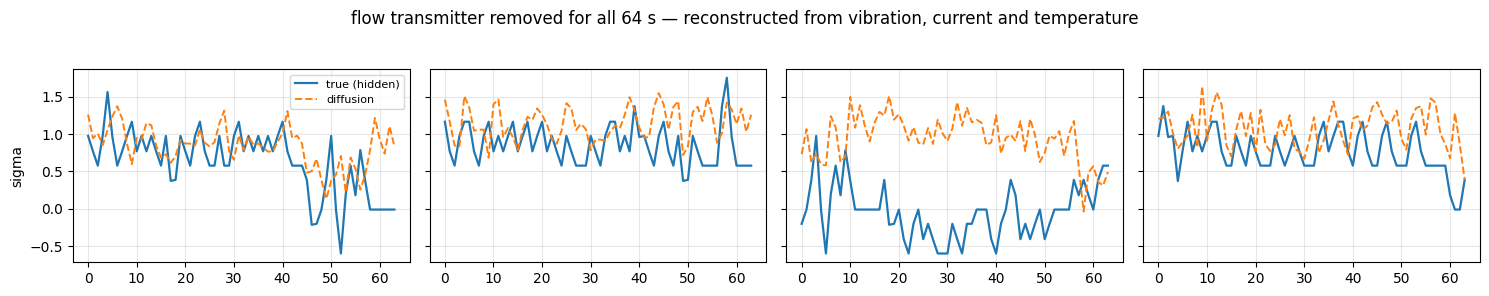

In [21]:
#@title what a reconstructed flow meter looks like
ci = CHANNELS.index("Volume Flow RateRMS")
rec = recons["Volume Flow RateRMS"]
fig, axes = plt.subplots(1, 4, figsize=(15, 2.8), sharey=True)
for j, ax in enumerate(axes):
    ax.plot(truth[j, ci].cpu().numpy(), lw=1.6, label="true (hidden)")
    ax.plot(rec[j, ci], lw=1.4, ls="--", label="diffusion")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("sigma"); axes[0].legend(fontsize=8)
fig.suptitle("flow transmitter removed for all 64 s — reconstructed from vibration, current and temperature", y=1.04)
plt.tight_layout(); plt.show()

The split verdict is the useful one.

For a **short gap**, linear interpolation wins or ties on the smooth tags and the diffusion model is not worth the compute. Twenty seconds of a signal with lag-1 autocorrelation near one is a straight line, and a straight line is the right answer.

For a **dead transmitter**, interpolation has nothing to work with and the comparison changes completely: the diffusion model beats both predicting the mean and a cross-channel least-squares fit, because it has learned the *joint* behaviour of six tags rather than a single linear map. That is the case that actually shows up in the control room, and it is the one where a generative model is the only tool that applies.

## Job 3 — detecting real faults

The model has never seen a fault. It has only learned what healthy looks like. That is exactly the position you are in with a new unit: plenty of normal history, no labelled failures.

**The score.** Take a window, noise it to a fixed level `t`, ask the model to predict the noise, and measure how wrong it is. Healthy windows lie where the model has probability mass and it predicts well; a faulted window does not, and the error rises. Averaging over several fixed noise draws keeps the score deterministic.

**Why a *large* `t`.** At `t = 10` the window is barely perturbed and denoising is a local smoothing problem the model solves about equally well on healthy and faulted data — it still detects something, but distinctly worse. As `t` grows, more of the window's structure is destroyed, and rebuilding it forces the model to lean on what it knows about healthy operation; a faulted window is then reconstructed towards the healthy manifold and the error jumps. Detection improves accordingly and then sits on a broad plateau from `t = 100` to `t = 350`, so the exact value is not a tuned knob. We fix `t = 200`.

**Per-channel calibration.** The six tags do not have equally predictable dynamics — a noisy tag contributes a large error even when healthy. We divide each channel's error by its mean error on **held-out healthy validation windows**, then average. Calibrating on validation rather than test keeps the test set clean, and the per-channel ratios are what give us fault localisation for free.

**Baselines.** Two, both of which a process engineer already has: PCA reconstruction error, and Hotelling's T² — the standard multivariate SPC statistic. If diffusion cannot get near these it does not belong on the unit.

In [22]:
#@title anomaly score
T_SCORE, N_DRAWS = 200, 8

@torch.no_grad()
def channel_errors(X, t_fixed=T_SCORE, draws=N_DRAWS, bs=512):
    """mean epsilon-prediction error per (window, channel)."""
    out = np.zeros((len(X), C))
    for r in range(draws):
        g, parts = torch.Generator().manual_seed(1000 * t_fixed + r), []
        for i in range(0, len(X), bs):
            xb = X[i:i + bs].to(device)
            e  = torch.randn(xb.shape, generator=g).to(device)
            t  = torch.full((len(xb),), t_fixed, device=device, dtype=torch.long)
            parts.append(((ema(q_sample(xb, t, e), t) - e) ** 2).mean(2).cpu().numpy())
        out += np.concatenate(parts)
    return out / draws

baseline = channel_errors(val_t).mean(0)                 # calibration: healthy validation only
cal_test = channel_errors(test_t) / baseline             # (N, C) ratios vs healthy
score    = cal_test.mean(1)
print("calibration (mean epsilon-error on healthy validation windows):")
for c, b in zip(CHANNELS, baseline): print(f"  {c:22s} {b:.4f}")

calibration (mean epsilon-error on healthy validation windows):
  Accelerometer1RMS      0.1418
  Accelerometer2RMS      0.1397
  Current                0.4466
  Temperature            0.1328
  Thermocouple           0.0677
  Volume Flow RateRMS    0.1156


  t =  10   mean-per-fault ROC-AUC 0.780


  t =  50   mean-per-fault ROC-AUC 0.853


  t = 100   mean-per-fault ROC-AUC 0.875


  t = 150   mean-per-fault ROC-AUC 0.884


  t = 200   mean-per-fault ROC-AUC 0.887


  t = 250   mean-per-fault ROC-AUC 0.893


  t = 300   mean-per-fault ROC-AUC 0.894


  t = 350   mean-per-fault ROC-AUC 0.877


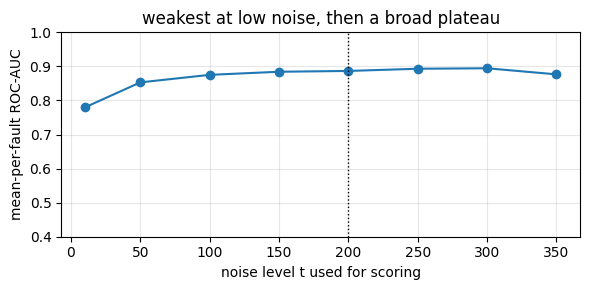

In [23]:
#@title how sensitive is this to t?
from sklearn.metrics import roc_auc_score

def mean_per_fault_auc(s):
    return np.mean([roc_auc_score(y_test[exp_id == i], s[exp_id == i]) for i in FAULTS])

sens = []
for t_try in [10, 50, 100, 150, 200, 250, 300, 350]:
    b = channel_errors(val_t, t_try).mean(0)
    s = (channel_errors(test_t, t_try) / b).mean(1)
    sens.append((t_try, mean_per_fault_auc(s)))
    print(f"  t = {t_try:3d}   mean-per-fault ROC-AUC {sens[-1][1]:.3f}")

plt.figure(figsize=(6, 3))
plt.plot(*zip(*sens), marker="o")
plt.axvline(T_SCORE, color="k", ls=":", lw=1); plt.ylim(0.4, 1.0)
plt.xlabel("noise level t used for scoring"); plt.ylabel("mean-per-fault ROC-AUC")
plt.title("weakest at low noise, then a broad plateau"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Why we score each experiment separately.** Pooling every window into one ROC curve mixes two different questions: is this window faulted, and which experiment did it come from? The rig keeps warming up all session, and the fault experiments were recorded *after* the healthy run — the pre-fault seconds of the later files sit several sigma from the training block on some tags, purely from drift. A pooled ROC partly measures that drift. Computing ROC-AUC *within* each experiment and averaging asks the question you actually care about: on this unit, on this day, can you separate the upset from the healthy period immediately before it? We report both, and the gap between them is itself informative.

In [24]:
#@title diffusion vs the tools you already have
from sklearn.decomposition import PCA

flat_tr = x_train.reshape(len(x_train), -1).astype(np.float64)   # float64 throughout: T2 inverts a covariance
flat_te = x_test.reshape(len(x_test), -1).astype(np.float64)
pca = PCA(8).fit(flat_tr)
pca_score = ((flat_te - pca.inverse_transform(pca.transform(flat_te))) ** 2).mean(1)

cov  = np.cov(x_train.reshape(-1, C).T.astype(np.float64))
icov = np.linalg.pinv(cov)
dev_ = x_test.mean(1).astype(np.float64)
t2_score = np.einsum("ij,jk,ik->i", dev_, icov, dev_)

rows = []
for i, name in FAULTS.items():
    m = exp_id == i
    faulted = m & y_test
    top = int(cal_test[faulted].mean(0).argmax())
    rows.append({"fault": name,
                 "diffusion": roc_auc_score(y_test[m], score[m]),
                 "PCA-8":     roc_auc_score(y_test[m], pca_score[m]),
                 "T-squared": roc_auc_score(y_test[m], t2_score[m]),
                 "diffusion points at": CHANNELS[top],
                 "x baseline": cal_test[faulted].mean(0)[top]})
res = pd.DataFrame(rows, index=[f"other/{i}" for i in FAULTS])
print(res.round(3).to_string())
print(f"\nMEAN per-fault ROC-AUC   diffusion {res['diffusion'].mean():.3f} | PCA-8 {res['PCA-8'].mean():.3f} | T2 {res['T-squared'].mean():.3f}")
print(f"POOLED     ROC-AUC       diffusion {roc_auc_score(y_test, score):.3f} | PCA-8 {roc_auc_score(y_test, pca_score):.3f} | T2 {roc_auc_score(y_test, t2_score):.3f}")

                                  fault  diffusion  PCA-8  T-squared  diffusion points at  x baseline
other/5         rotor imbalance (sharp)      0.986  0.913      1.000    Accelerometer2RMS      30.774
other/6        rotor imbalance (linear)      1.000  0.997      1.000    Accelerometer2RMS      29.678
other/7          rotor imbalance (step)      1.000  0.989      1.000    Accelerometer2RMS      30.285
other/8       rotor imbalance (impulse)      0.591  0.406      0.785    Accelerometer2RMS       5.961
other/9   rotor imbalance (exponential)      0.998  0.981      0.999    Accelerometer2RMS      30.066
other/10            slow water increase      0.931  0.825      0.935    Accelerometer2RMS      13.314
other/11          sudden water increase      0.990  0.998      0.998    Accelerometer2RMS      18.121
other/12      cavitation (tank drained)      0.895  0.887      0.887  Volume Flow RateRMS      33.229
other/13   cavitation (two-phase inlet)      0.481  0.517      0.479  Volume Flow 

Read the `diffusion points at` column carefully, because it is the result worth taking home.

Nobody told the model what a rotor imbalance is, what cavitation is, or which tag belongs to which failure mode. It was trained on healthy data with no labels at all. Yet wherever the physics is unambiguous, the channel whose reconstruction error rises most is the right one: **rotor imbalance lands on an accelerometer, both cavitation experiments land on the flow meter, and the hot-water experiment lands on the fluid thermocouple**. The two water-inventory faults also surface on the accelerometer, which is plausible — changing the loop inventory changes how the pump is loaded — but we have no independent ground truth for those, so treat that pair as unconfirmed.

A scalar alarm tells you something is wrong. This tells the panel operator which instrument to look at first, and it comes out of a model that was never shown a fault.

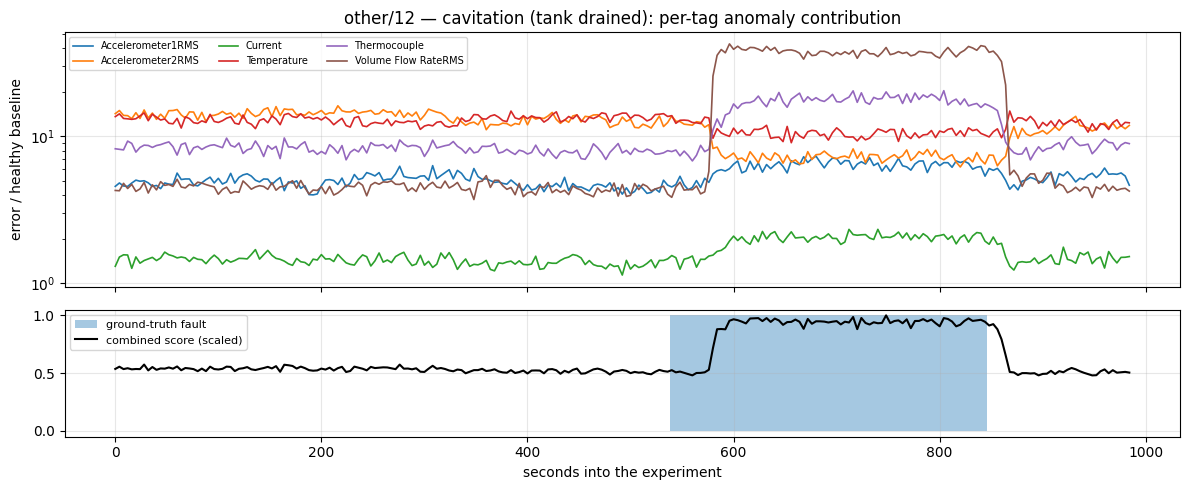

In [25]:
#@title one experiment, second by second
SHOW = 12   # cavitation (tank drained)
m = exp_id == SHOW
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
t_axis = np.arange(m.sum()) * STRIDE_TE
for ci, c in enumerate(CHANNELS):
    axes[0].plot(t_axis, cal_test[m][:, ci], lw=1.2, label=c)
axes[0].set_yscale("log"); axes[0].set_ylabel("error / healthy baseline")
axes[0].set_title(f"other/{SHOW} — {FAULTS[SHOW]}: per-tag anomaly contribution")
axes[0].legend(fontsize=7, ncol=3); axes[0].grid(alpha=0.3)
axes[1].fill_between(t_axis, 0, y_test[m].astype(float), step="mid", alpha=0.4, label="ground-truth fault")
axes[1].plot(t_axis, score[m] / score[m].max(), lw=1.5, color="k", label="combined score (scaled)")
axes[1].set_xlabel("seconds into the experiment"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Where this leaves you

**What worked.** One unconditional DDPM, trained on roughly two and a half hours of unlabelled healthy data, produced synthetic windows whose cross-channel correlation structure matches the real thing to within a few percent; reconstructed a completely dead transmitter better than either a cross-channel regression or the channel mean; and separated the upset from healthy operation in eight of ten unseen fault experiments, pointing at the physically correct instrument wherever the physics is unambiguous.

**What did not.** Hotelling's T² — a statistic from 1931 that fits on one line — is a slightly *better* pure detector than the diffusion model here, and it costs nothing to compute. If a single alarm flag is all you need, use T². The diffusion model does comfortably beat PCA reconstruction error, but that is not the point either. It earns its place by doing three jobs with one set of weights, and by naming the guilty instrument without ever being told what a fault is — neither of which T² gives you.

**The honest limitations.**

- Two of ten faults are essentially missed. `other/8` is a Dirac-impulse imbalance shorter than the 64-second window, so it is diluted by the surrounding healthy seconds — a shorter window would catch it. `other/13`, two-phase flow at the inlet, drifts in the same direction the healthy warm-up already drifts, so the model has no reason to be surprised.
- The effective training set is roughly 120 independent windows. Everything here would firm up considerably with a week of history rather than an afternoon.
- The model is tied to one operating point. A refinery pump runs at many, so a production version would condition on setpoint, or train per regime.
- `Thermocouple` is reproduced with too little persistence. Very smooth, near-integrated tags want either a longer window or an explicit trend term.

**Worth trying next.** Shorten the window to 16 s and watch `other/8` become detectable while the slow faults get worse. Condition the model on operating regime and train across all three SKAB setpoints. Swap the ε-prediction objective for v-prediction. Or hold out `valve1` entirely and see whether a model trained at 125 L/min recognises a fault at 32 L/min — it will not, and understanding why is the most useful thing on this list.

**References.** Ho et al., *Denoising Diffusion Probabilistic Models* (2020), [arXiv:2006.11239](https://arxiv.org/abs/2006.11239) · Nichol & Dhariwal, *Improved Denoising Diffusion Probabilistic Models* (2021), [arXiv:2102.09672](https://arxiv.org/abs/2102.09672) · Lugmayr et al., *RePaint* (2022), [arXiv:2201.09865](https://arxiv.org/abs/2201.09865) · Tashiro et al., *CSDI* (2021), [arXiv:2107.03502](https://arxiv.org/abs/2107.03502) · Katser & Kozitsin, *Skoltech Anomaly Benchmark (SKAB)*, [github.com/waico/SKAB](https://github.com/waico/SKAB)